# DreamBooth Personalization with LoRA on SD 3.5
Samsung DS^2 academy  - Creating Images with Generative AI

## Import necessary packages

In [ ]:
!pip install -U torchao

In [ ]:
from huggingface_hub import login
login()

In [ ]:
import os
import math
import numpy as np
from pathlib import Path

import torch
from PIL import Image
from tqdm.auto import tqdm

from diffusers import (
    AutoencoderKL,
    FlowMatchEulerDiscreteScheduler,
    SD3Transformer2DModel,
    StableDiffusion3Pipeline,
)
from diffusers.optimization import get_scheduler
from diffusers.training_utils import (
    cast_training_params,
    compute_density_for_timestep_sampling,
    compute_loss_weighting_for_sd3,
    free_memory,
)
from accelerate import Accelerator
from accelerate.utils import set_seed
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import CLIPTokenizer, CLIPTextModelWithProjection

import matplotlib.pyplot as plt
from torchvision.utils import make_grid


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Download sample images

In [ ]:
instance_data_dir = "instance_images"
os.makedirs(instance_data_dir, exist_ok=True)

from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="diffusers/dog-example",
    repo_type="dataset",
    local_dir=instance_data_dir,
    ignore_patterns=[".gitattributes"],
)

image_files = [f for f in os.listdir(instance_data_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
assert len(image_files) > 0, f"'{instance_data_dir}' not found!"

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

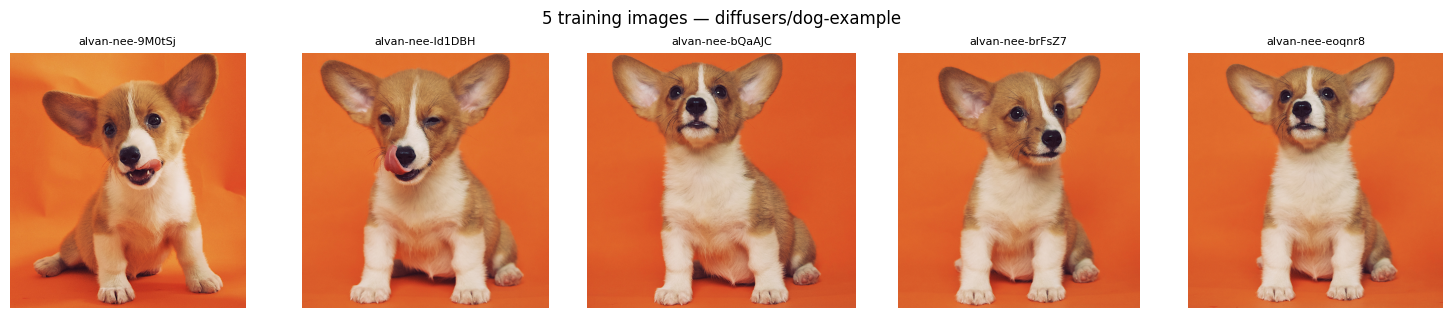

In [ ]:
image_paths = sorted(os.path.join(instance_data_dir, f) for f in image_files)

fig, axes = plt.subplots(1, len(image_paths), figsize=(3 * len(image_paths), 3.2))
for ax, path in zip(np.atleast_1d(axes), image_paths):
    ax.imshow(Image.open(path))
    ax.set_title(os.path.basename(path)[:16], fontsize=8)
    ax.axis("off")
fig.suptitle(f"{len(image_paths)} training images — diffusers/dog-example")
fig.tight_layout()
plt.show()

## Set the directories and model ids

학습에 필요한 모든 값을 여기서 직접 수정합니다.

In [ ]:
# --- 모델 및 경로 설정 ---
pretrained_model_name_or_path = "stabilityai/stable-diffusion-3.5-medium"
output_dir = "./outputs/dreambooth_lora_sd3"

# --- 프롬프트 설정 ---
instance_prompt = "a photo of sks dog"
validation_prompt = "a photo of sks dog in a bucket"

# --- 학습 파라미터 ---
resolution = 256
train_batch_size = 1
gradient_accumulation_steps = 2
max_train_steps = 300
learning_rate = 5e-4
lr_scheduler_name = "constant"
lr_warmup_steps = 0
seed = 42
lora_rank = 4
weighting_scheme = "logit_normal"   # reference 기본값

# --- 시스템 및 기타 설정 ---
mixed_precision = "fp16"
num_validation_images = 4


## Dataset declare and helper functions

In [ ]:
class DreamBoothDataset(Dataset):
    """학습 이미지를 불러오고 전처리하는 데이터셋 클래스"""
    def __init__(self, data_root, prompt, size=1024, repeats=1):
        self.size = size
        self.prompt = prompt
        self.data_root = Path(data_root)
        if not self.data_root.exists():
            raise ValueError(f"Instance images root {self.data_root} doesn't exist.")

        self.image_paths = [p for p in self.data_root.iterdir() if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        self.num_instance_images = len(self.image_paths)
        self._length = self.num_instance_images * repeats

        self.image_transforms = transforms.Compose([
            transforms.Resize(self.size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomCrop(self.size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        image_path = self.image_paths[index % self.num_instance_images]
        image = Image.open(image_path).convert("RGB")
        return {
            "instance_images": self.image_transforms(image),
            "instance_prompt": self.prompt
        }

def collate_fn(examples):
    pixel_values = torch.stack([e["instance_images"] for e in examples])
    return {"pixel_values": pixel_values.to(memory_format=torch.contiguous_format).float()}

def encode_prompt(text_encoders, tokenizers, prompt, device, joint_attention_dim=4096):
    """CLIP-L / CLIP-G 두 개로 프롬프트를 인코딩한다."""
    prompt_embeds_list = []
    pooled_prompt_embeds_list = []

    for tokenizer, text_encoder in zip(tokenizers, text_encoders):
        text_inputs = tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
        prompt_embeds = text_encoder(text_inputs.input_ids.to(device), output_hidden_states=True)

        pooled_prompt_embeds_list.append(prompt_embeds[0])
        prompt_embeds_list.append(prompt_embeds.hidden_states[-2])

    clip_prompt_embeds = torch.cat(prompt_embeds_list, dim=-1)
    t5_prompt_embeds = torch.zeros(
        (clip_prompt_embeds.shape[0], 77, joint_attention_dim),
        device=device, dtype=clip_prompt_embeds.dtype,
    )
    clip_prompt_embeds = torch.nn.functional.pad(
        clip_prompt_embeds, (0, joint_attention_dim - clip_prompt_embeds.shape[-1]))

    final_prompt_embeds = torch.cat([clip_prompt_embeds, t5_prompt_embeds], dim=-2)
    final_pooled_prompt_embeds = torch.cat(pooled_prompt_embeds_list, dim=-1)

    return final_prompt_embeds, final_pooled_prompt_embeds

## Accelerator and model loading

`Accelerator`가 mixed precision과 gradient accumulation을 관리합니다.
SD3.5는 tokenizer와 text encoder가 3개(CLIP-L, CLIP-G, T5-XXL)라 각각 따로 로드합니다.

In [ ]:
set_seed(seed)
os.makedirs(output_dir, exist_ok=True)
accelerator = Accelerator(
    gradient_accumulation_steps=gradient_accumulation_steps,
    mixed_precision=mixed_precision,
)

print("Loading models...")
# Tokenizers
tokenizer_one = CLIPTokenizer.from_pretrained(pretrained_model_name_or_path, subfolder="tokenizer")
tokenizer_two = CLIPTokenizer.from_pretrained(pretrained_model_name_or_path, subfolder="tokenizer_2")
tokenizers = [tokenizer_one, tokenizer_two]

# Text Encoders
print("Loading Text Encoders...")
text_encoder_one = CLIPTextModelWithProjection.from_pretrained(pretrained_model_name_or_path, subfolder="text_encoder")
text_encoder_two = CLIPTextModelWithProjection.from_pretrained(pretrained_model_name_or_path, subfolder="text_encoder_2")
text_encoders = [text_encoder_one, text_encoder_two]

# VAE, Transformer, Scheduler
print("Loading VAE, Transformer, and Scheduler...")
vae = AutoencoderKL.from_pretrained(pretrained_model_name_or_path, subfolder="vae")
transformer = SD3Transformer2DModel.from_pretrained(pretrained_model_name_or_path, subfolder="transformer")
noise_scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(pretrained_model_name_or_path, subfolder="scheduler")
print("Models loaded.")

Loading models...


tokenizer_config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

transformer/diffusion_pytorch_model.safe(…): reconstructing file:   0%|          |  0.00B / 4.94GB            

transformer/diffusion_pytorch_model.safe(…): downloading bytes:           |  0.00B            

scheduler_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Models loaded.


## Freeze the base model and attach the LoRA adapter

VAE, text encoder, transformer를 전부 freeze한 뒤 transformer의 attention projection에만 LoRA를 붙입니다.


In [ ]:
vae.requires_grad_(False)
for te in text_encoders: te.requires_grad_(False)
transformer.requires_grad_(False)

weight_dtype = torch.float16 if mixed_precision == "fp16" else torch.float32
vae.to(accelerator.device, dtype=torch.float32) # VAE는 float32로 유지
for te in text_encoders: te.to(accelerator.device, dtype=weight_dtype)
transformer.to(accelerator.device, dtype=weight_dtype)

# LoRA 어댑터 추가
transformer.add_adapter(LoraConfig(r=lora_rank, lora_alpha=lora_rank, target_modules=["attn.to_q", "attn.to_k", "attn.to_v", "attn.to_out.0"]))
if mixed_precision == "fp16":
    cast_training_params(transformer, dtype=torch.float32)

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in SD3Transformer2DModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


## Optimizer, dataloader, and `accelerator.prepare`

`params_to_optimize`는 `requires_grad=True`인 파라미터, 즉 LoRA 어댑터만 모읍니다.
`accelerator.prepare`가 device 배치와 mixed precision 래핑을 한 번에 처리합니다.

In [ ]:
params_to_optimize = list(filter(lambda p: p.requires_grad, transformer.parameters()))
optimizer = torch.optim.AdamW(params_to_optimize, lr=learning_rate)
lr_scheduler = get_scheduler(lr_scheduler_name, optimizer=optimizer, num_warmup_steps=lr_warmup_steps, num_training_steps=max_train_steps)
train_dataset = DreamBoothDataset(data_root=instance_data_dir, prompt=instance_prompt, size=resolution)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=collate_fn)

transformer, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(transformer, optimizer, train_dataloader, lr_scheduler)

## Pre-compute the text embeddings

프롬프트가 `instance_prompt` 하나로 고정이므로 text embedding을 매 스텝 다시 계산할 이유가 없습니다.
한 번 계산한 뒤 text encoder를 완전히 해제합니다.

In [ ]:
print("Pre-calculating text embeddings...")
with torch.no_grad():
    prompt_embeds, pooled_prompt_embeds = encode_prompt(text_encoders, tokenizers, instance_prompt, accelerator.device,
                                                  transformer.config.joint_attention_dim)
# 프롬프트는 한 번만 인코딩하면 되므로 여기서 text encoder를 완전히 해제한다.
del text_encoder_one, text_encoder_two
del text_encoders, tokenizers
free_memory()

Pre-calculating text embeddings...


## Training loop

Flow matching: `noisy = (1-σ)·x₀ + σ·ε`를 만들고 모델 예측을 x₀ 방향으로 환산해 손실을 구합니다.

`gradient_accumulation_steps` 때문에 optimizer step이 매 배치마다 일어나지 않습니다.
progress bar와 `global_step`은 `accelerator.sync_gradients`가 True일 때만 갱신합니다.

In [ ]:
print("***** Running training *****")
print(f"  Num examples = {len(train_dataset)}")
print(f"  Total optimization steps = {max_train_steps}")

progress_bar = tqdm(range(max_train_steps), disable=not accelerator.is_local_main_process)
progress_bar.set_description("Training Steps")
global_step = 0

vae_shift_factor = vae.config.shift_factor
vae_scale_factor = vae.config.scaling_factor

# 학습 시작
num_update_steps_per_epoch = math.ceil(len(train_dataloader) / gradient_accumulation_steps)
num_train_epochs = math.ceil(max_train_steps / num_update_steps_per_epoch)
print(f"  Steps per epoch = {num_update_steps_per_epoch}, epochs = {num_train_epochs}")

for epoch in range(num_train_epochs):
    transformer.train()
    for step, batch in enumerate(train_dataloader):
        with accelerator.accumulate(transformer):
            # 입력 준비
            with torch.no_grad():
                latents = vae.encode(batch["pixel_values"].to(vae.dtype)).latent_dist.sample()
                model_input = (latents - vae_shift_factor) * vae_scale_factor
                model_input = model_input.to(dtype=weight_dtype)

            noise = torch.randn_like(model_input)
            bsz = model_input.shape[0]

            # 노이즈 추가
            u = compute_density_for_timestep_sampling(
                weighting_scheme=weighting_scheme, batch_size=bsz,
                logit_mean=0.0, logit_std=1.0, mode_scale=1.29,
            )
            indices = (u * noise_scheduler.config.num_train_timesteps).long()
            timesteps = noise_scheduler.timesteps.to(model_input.device)[indices]
            sigmas = noise_scheduler.sigmas.to(device=model_input.device, dtype=weight_dtype)[indices].flatten().reshape(bsz, 1, 1, 1)
            noisy_model_input = (1.0 - sigmas) * model_input + sigmas * noise

            # 예측 및 손실 계산
            model_pred = transformer(hidden_states=noisy_model_input, timestep=timesteps, encoder_hidden_states=prompt_embeds, pooled_projections=pooled_prompt_embeds).sample
            model_pred = model_pred * (-sigmas) + noisy_model_input
            weighting = compute_loss_weighting_for_sd3(weighting_scheme=weighting_scheme, sigmas=sigmas)
            loss = torch.mean((weighting * (model_pred.float() - model_input.float()) ** 2).reshape(model_input.shape[0], -1), 1).mean()

            accelerator.backward(loss)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        # 진행 상황 업데이트 및 체크포인트 저장
        if accelerator.sync_gradients:
            progress_bar.update(1)
            global_step += 1
            progress_bar.set_postfix(loss=loss.detach().item())

        if global_step >= max_train_steps:
            break
    if global_step >= max_train_steps:
        break

***** Running training *****
  Num examples = 5
  Total optimization steps = 300


  0%|          | 0/300 [00:00<?, ?it/s]

  Steps per epoch = 3, epochs = 100


## Save the LoRA weights

transformer 전체가 아닌 LoRA 어댑터 가중치만 저장합니다 (`get_peft_model_state_dict`).

In [ ]:
accelerator.wait_for_everyone()
if accelerator.is_local_main_process:
    print("Saving final LoRA weights...")
    unwrapped_transformer = accelerator.unwrap_model(transformer)
    StableDiffusion3Pipeline.save_lora_weights(
        save_directory=output_dir,
        transformer_lora_layers=get_peft_model_state_dict(unwrapped_transformer),
    )

print("✅ Training finished successfully!")

Saving final LoRA weights...
✅ Training finished successfully!


## Validation — generate with the trained LoRA


In [ ]:
transformer, optimizer, lr_scheduler, train_dataloader = accelerator.free_memory(
    transformer, optimizer, lr_scheduler, train_dataloader)
for _name in ["unwrapped_transformer", "vae"]:
    globals().pop(_name, None)
free_memory()

print("Running validation...")
pipeline = StableDiffusion3Pipeline.from_pretrained(
    pretrained_model_name_or_path,
    text_encoder_3=None,
    tokenizer_3=None,
    torch_dtype=weight_dtype,
)
pipeline.load_lora_weights(output_dir)
pipeline.to(accelerator.device)

Running validation...


model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


StableDiffusion3Pipeline {
  "_class_name": "StableDiffusion3Pipeline",
  "_diffusers_version": "0.39.0",
  "_name_or_path": "stabilityai/stable-diffusion-3.5-medium",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "text_encoder_3": [
    null,
    null
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_3": [
    null,
    null
  ],
  "transformer": [
    "diffusers",
    "SD3Transformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

같은 프롬프트, 같은 seed로 LoRA를 켰을 때와 껐을 때를 비교합니다.

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

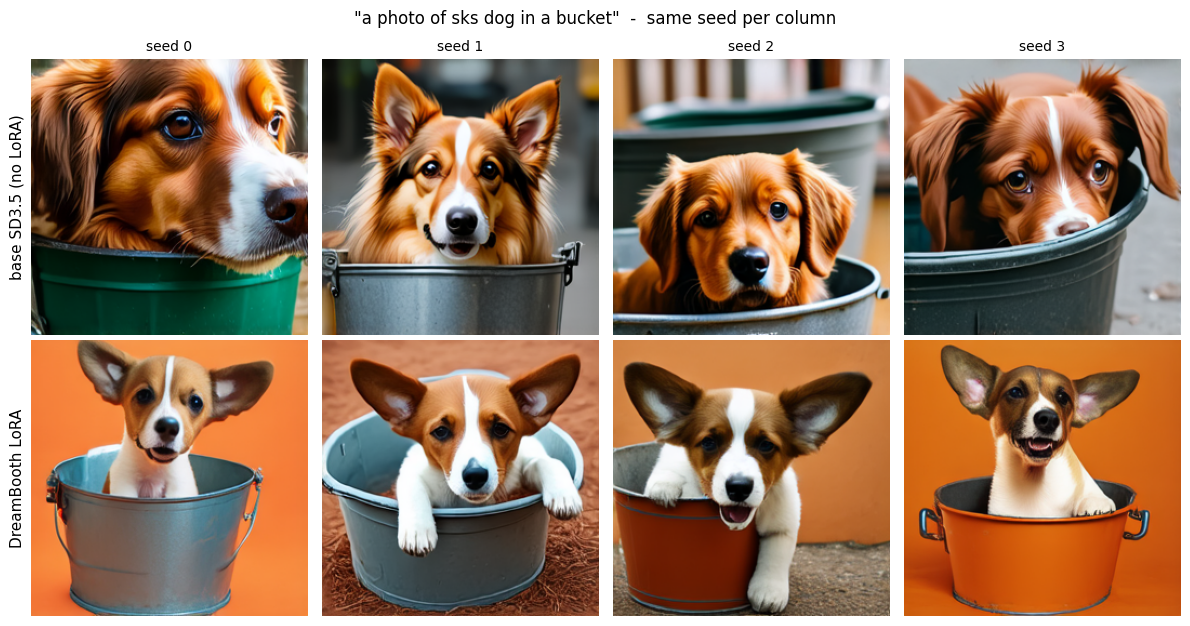

In [ ]:
SEEDS = [0, 1, 2, 3]

rows = []
for label, use_lora in [("base SD3.5 (no LoRA)", False), ("DreamBooth LoRA", True)]:
    pipeline.enable_lora() if use_lora else pipeline.disable_lora()
    imgs = []
    for s in SEEDS:
        gen = torch.Generator(device=pipeline.device).manual_seed(s)
        imgs.append(pipeline(prompt=validation_prompt, generator=gen,
                             height=resolution, width=resolution).images[0])
    rows.append((label, imgs))
pipeline.enable_lora()

fig, axes = plt.subplots(len(rows), len(SEEDS), figsize=(3.0 * len(SEEDS), 3.2 * len(rows)))
for r, (label, imgs) in enumerate(rows):
    for c, img in enumerate(imgs):
        ax = axes[r][c]
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(f"seed {SEEDS[c]}", fontsize=10)
    axes[r][0].set_ylabel(label, fontsize=11)

fig.suptitle(f'"{validation_prompt}"  -  same seed per column')
fig.tight_layout()
fig.savefig(Path(output_dir) / "lora_vs_base.png", dpi=110, bbox_inches="tight")
plt.show()